# MNIST Classification with a Two-Layer Convolutional Network

This notebook trains a compact convolutional classifier for MNIST. The model uses two convolutional layers: the first has 32 filters and the second has 64 filters. After training, the notebook visualizes the mean activation map of the second convolutional layer for each digit class.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist, mnist

np.random.seed(7)
tf.keras.utils.set_random_seed(7)


## Load and Prepare MNIST

Convolutional layers expect image tensors, so the MNIST images are kept as $28 \times 28$ arrays and reshaped to include a single grayscale channel.


In [11]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

num_classes = len(np.unique(y_train))

X_train.shape, y_train.shape, X_test.shape, y_test.shape, num_classes


((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,), 10)

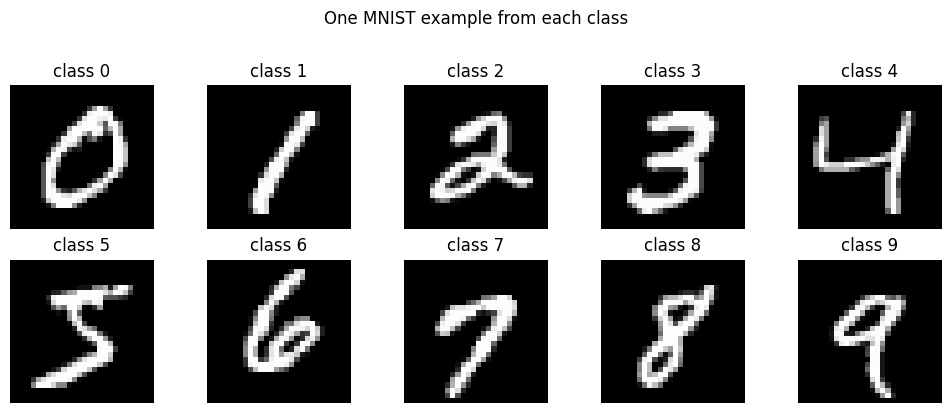

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    sample_index = np.flatnonzero(y_train == digit)[0]
    ax.imshow(X_train[sample_index, :, :, 0], cmap="gray")
    ax.set_title(f"class {digit}")
    ax.axis("off")
fig.suptitle("One MNIST example from each class", y=1.02)
plt.tight_layout()


## Model

The convolutional body has exactly two `Conv2D` layers for local feature extraction. Pooling reduces spatial resolution after each convolutional stage, and the dense head maps the learned features to the ten digit classes.


In [13]:
inputs = tf.keras.layers.Input(shape=(28, 28, 1), name="image")

x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="conv_32",
)(inputs)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool_32")(x)

x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="conv_64",
)(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool_64")(x)

x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(128, activation="relu", name="dense_128")(x)
x = tf.keras.layers.Dropout(0.25, name="dropout")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probability")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="mnist_two_layer_cnn")
model.summary()


Model: "mnist_two_layer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_32 (MaxPooling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_64 (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probability (Dense)       │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate

Three epochs are enough for a workshop-scale run while still showing the behavior of the convolutional representation. Increase `epochs` if you want a stronger final classifier.


In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 144ms/step - accuracy: 0.9266 - loss: 0.2403 - val_accuracy: 0.9813 - val_loss: 0.0623
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 60s 142ms/step - accuracy: 0.9784 - loss: 0.0686 - val_accuracy: 0.9860 - val_loss: 0.0463
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 145ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9893 - val_loss: 0.0383


In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_accuracy:.4f}")


test loss: 0.0358
test accuracy: 0.9889


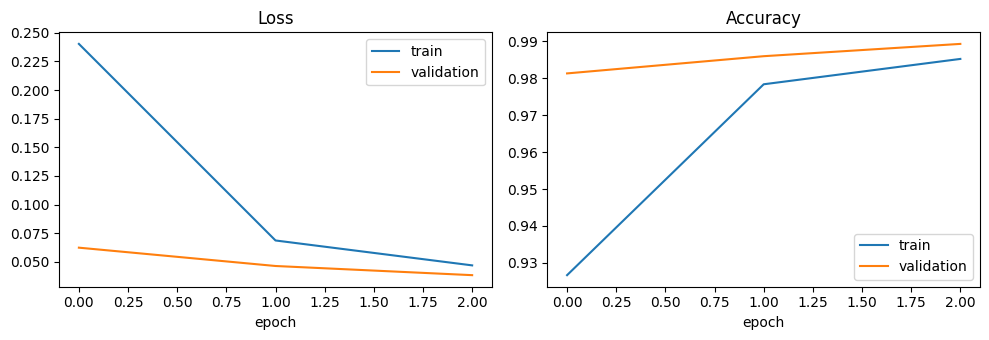

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()


## Mean Feature Map by Class

The next cells inspect the second convolutional layer (`conv_64`). For each test image, the 64 channels are averaged into one spatial activation map. Then those maps are averaged again within each true MNIST class.


In [17]:
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("conv_64").output,
    name="conv_64_feature_extractor",
)

feature_maps = feature_extractor.predict(X_test, batch_size=256, verbose=0)
image_level_mean_maps = feature_maps.mean(axis=-1)

class_mean_feature_maps = np.stack([
    image_level_mean_maps[y_test == digit].mean(axis=0)
    for digit in range(num_classes)
])

class_mean_feature_maps.shape


(10, 14, 14)

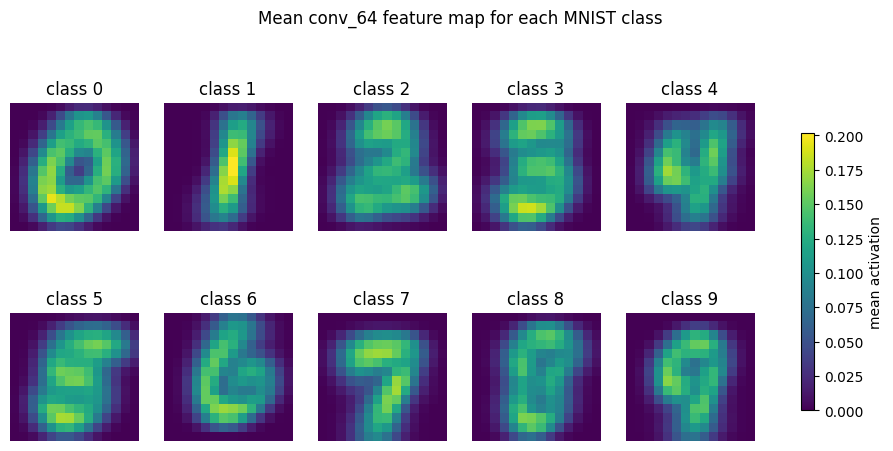

In [18]:
vmin = class_mean_feature_maps.min()
vmax = class_mean_feature_maps.max()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flat):
    image = ax.imshow(
        class_mean_feature_maps[digit],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"class {digit}")
    ax.axis("off")

fig.suptitle("Mean conv_64 feature map for each MNIST class", y=1.02)
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.72, label="mean activation")
plt.show()


# Fashion-MNIST Classification with the Same Two-Layer CNN

This section repeats the same convolutional workflow for Fashion-MNIST. The architecture again uses a first `Conv2D` layer with 32 filters and a second `Conv2D` layer with 64 filters, followed by the same class-wise mean feature-map visualization.


In [19]:
(fashion_X_train, fashion_y_train), (fashion_X_test, fashion_y_test) = fashion_mnist.load_data()

fashion_X_train = fashion_X_train.astype("float32") / 255.0
fashion_X_test = fashion_X_test.astype("float32") / 255.0

fashion_X_train = fashion_X_train[..., np.newaxis]
fashion_X_test = fashion_X_test[..., np.newaxis]

fashion_class_names = np.array([
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
])
fashion_num_classes = len(fashion_class_names)

fashion_X_train.shape, fashion_y_train.shape, fashion_X_test.shape, fashion_y_test.shape, fashion_num_classes


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,), 10)

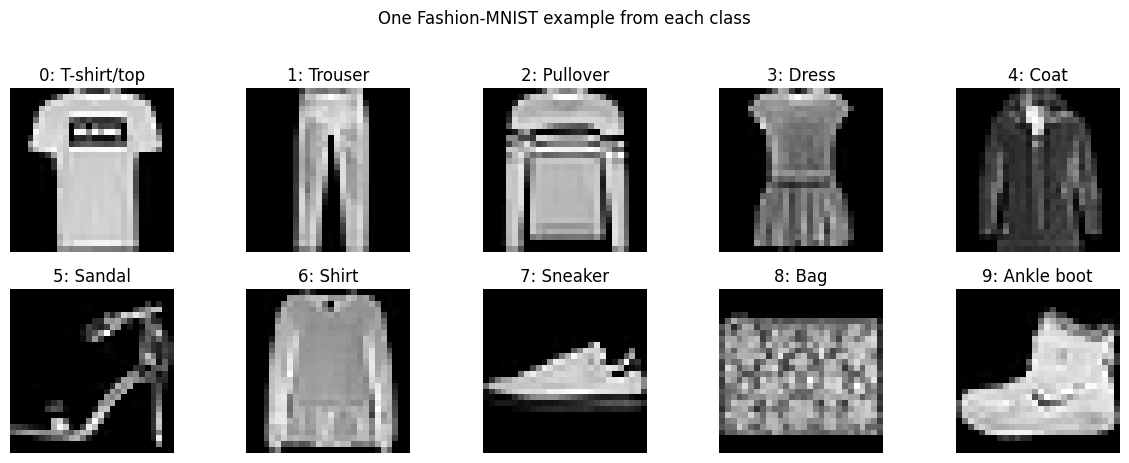

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(12, 4.5))
for class_id, ax in enumerate(axes.flat):
    sample_index = np.flatnonzero(fashion_y_train == class_id)[0]
    ax.imshow(fashion_X_train[sample_index, :, :, 0], cmap="gray")
    ax.set_title(f"{class_id}: {fashion_class_names[class_id]}")
    ax.axis("off")
fig.suptitle("One Fashion-MNIST example from each class", y=1.02)
plt.tight_layout()


## Fashion-MNIST Model

The model below deliberately mirrors the MNIST CNN: two convolutional layers with 32 and 64 filters, pooling after each stage, and a dense classifier for the ten Fashion-MNIST classes.


In [21]:
fashion_inputs = tf.keras.layers.Input(shape=(28, 28, 1), name="fashion_image")

fashion_x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="fashion_conv_32",
)(fashion_inputs)
fashion_x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fashion_pool_32")(fashion_x)

fashion_x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    name="fashion_conv_64",
)(fashion_x)
fashion_x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="fashion_pool_64")(fashion_x)

fashion_x = tf.keras.layers.Flatten(name="fashion_flatten")(fashion_x)
fashion_x = tf.keras.layers.Dense(128, activation="relu", name="fashion_dense_128")(fashion_x)
fashion_x = tf.keras.layers.Dropout(0.25, name="fashion_dropout")(fashion_x)
fashion_outputs = tf.keras.layers.Dense(
    fashion_num_classes,
    activation="softmax",
    name="fashion_class_probability",
)(fashion_x)

fashion_model = tf.keras.Model(
    inputs=fashion_inputs,
    outputs=fashion_outputs,
    name="fashion_mnist_two_layer_cnn",
)
fashion_model.summary()


Model: "fashion_mnist_two_layer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fashion_image (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_conv_32 (Conv2D)        │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_pool_32 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_conv_64 (Conv2D)        │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_pool_64 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_flatten (Flatten)       │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_dense_128 (Dense)       │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_dropout (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fashion_class_probability       │ (None, 10)             │         1,290 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fashion_history = fashion_model.fit(
    fashion_X_train,
    fashion_y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.8123 - loss: 0.5302 - val_accuracy: 0.8760 - val_loss: 0.3393
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 147ms/step - accuracy: 0.8814 - loss: 0.3343 - val_accuracy: 0.8962 - val_loss: 0.2874
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 145ms/step - accuracy: 0.8965 - loss: 0.2873 - val_accuracy: 0.9035 - val_loss: 0.2645


In [23]:
fashion_test_loss, fashion_test_accuracy = fashion_model.evaluate(
    fashion_X_test,
    fashion_y_test,
    verbose=0,
)
print(f"Fashion-MNIST test loss: {fashion_test_loss:.4f}")
print(f"Fashion-MNIST test accuracy: {fashion_test_accuracy:.4f}")


Fashion-MNIST test loss: 0.2847
Fashion-MNIST test accuracy: 0.8946


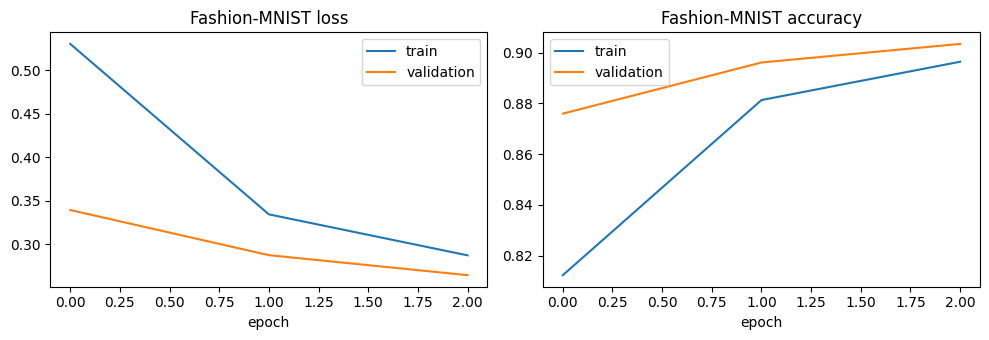

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(fashion_history.history["loss"], label="train")
axes[0].plot(fashion_history.history["val_loss"], label="validation")
axes[0].set_title("Fashion-MNIST loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(fashion_history.history["accuracy"], label="train")
axes[1].plot(fashion_history.history["val_accuracy"], label="validation")
axes[1].set_title("Fashion-MNIST accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()


## Fashion-MNIST Mean Feature Map by Class

As before, the feature extractor reads the second convolutional layer. The 64 channels are averaged into one spatial map per image, then averaged within each true Fashion-MNIST class.


In [25]:
fashion_feature_extractor = tf.keras.Model(
    inputs=fashion_model.input,
    outputs=fashion_model.get_layer("fashion_conv_64").output,
    name="fashion_conv_64_feature_extractor",
)

fashion_feature_maps = fashion_feature_extractor.predict(
    fashion_X_test,
    batch_size=256,
    verbose=0,
)
fashion_image_level_mean_maps = fashion_feature_maps.mean(axis=-1)

fashion_class_mean_feature_maps = np.stack([
    fashion_image_level_mean_maps[fashion_y_test == class_id].mean(axis=0)
    for class_id in range(fashion_num_classes)
])

fashion_class_mean_feature_maps.shape


(10, 14, 14)

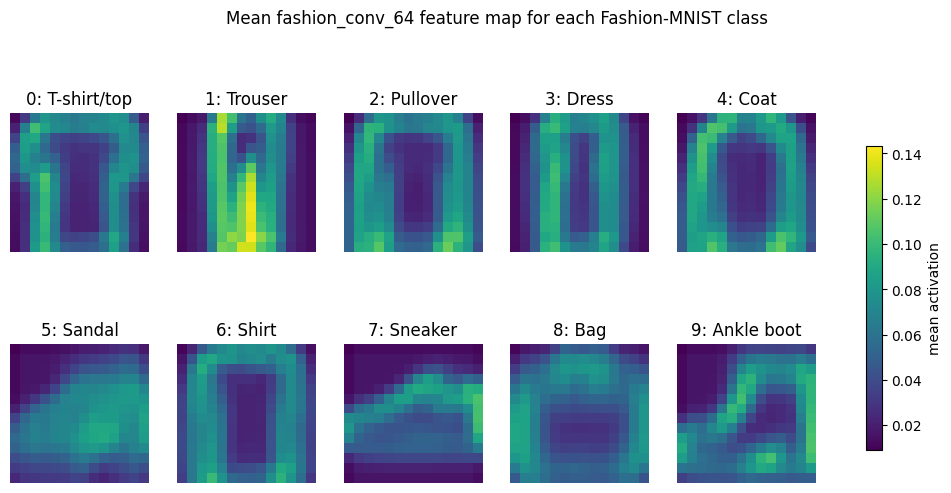

In [26]:
fashion_vmin = fashion_class_mean_feature_maps.min()
fashion_vmax = fashion_class_mean_feature_maps.max()

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for class_id, ax in enumerate(axes.flat):
    image = ax.imshow(
        fashion_class_mean_feature_maps[class_id],
        cmap="viridis",
        vmin=fashion_vmin,
        vmax=fashion_vmax,
    )
    ax.set_title(f"{class_id}: {fashion_class_names[class_id]}")
    ax.axis("off")

fig.suptitle("Mean fashion_conv_64 feature map for each Fashion-MNIST class", y=1.02)
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.72, label="mean activation")
plt.show()
